# Customer Segmentation with Honest Cluster Validation

## 01 — Data Understanding

This notebook explores and validates the Online Retail II dataset
before customer-level RFM feature engineering.

### Objectives

- Load the raw transaction data
- Understand the schema
- Inspect missing values
- Inspect duplicates
- Examine cancellations/returns
- Examine transaction dates
- Understand customer coverage
- Establish the analysis/reference date

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [2]:
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" 

DATA_PATH = RAW_DIR / "online_retail_II.xlsx"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Project root: /home/mulata_niguse/AI-Engineering/ecom-customer-segmentation-project
Data path: /home/mulata_niguse/AI-Engineering/ecom-customer-segmentation-project/data/raw/online_retail_II.xlsx
Exists: True


In [3]:
excel_file = pd.ExcelFile(DATA_PATH)

excel_file.sheet_names

['Year 2009-2010', 'Year 2010-2011']

In [4]:
sheets = pd.read_excel(DATA_PATH, sheet_name=None)

for name, df in sheets.items():
    print(name, df.shape)

Year 2009-2010 (525461, 8)
Year 2010-2011 (541910, 8)


In [10]:
df = pd.concat(
    sheets.values(),
    ignore_index=True
)
df.tail()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.0,France


In [11]:
print("Combined shape:", df.shape)

Combined shape: (1067371, 8)


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [6]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing

Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

In [7]:
missing_pct = (
    df.isna()
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

missing_pct

Customer ID    22.766873
Description     0.410541
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

In [8]:
missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_pct
})

missing_summary

,missing_count,missing_percent
Customer ID,243007,22.766873
Description,4382,0.410541
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


In [13]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_summary

,Missing Count,Missing %
Invoice,0,0.00
StockCode,0,0.00
Description,4382,0.41
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Customer ID,243007,22.77
Country,0,0.00


## Convert the date

In [14]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [15]:
print("Date range:")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())

Date range:
2009-12-01 07:45:00
2011-12-09 12:50:00


## Investigate cancellations

In [16]:
df["Invoice"] = df["Invoice"].astype(str)

cancelled = df["Invoice"].str.startswith("C")

print("Cancellation rows:", cancelled.sum())
print("Cancellation percentage:", round(cancelled.mean() * 100, 2), "%")

Cancellation rows: 19494
Cancellation percentage: 1.83 %


In [17]:
df.loc[cancelled].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


## Check negative quantities

In [18]:
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero quantities:", (df["Quantity"] == 0).sum())

Negative quantities: 22950
Zero quantities: 0


In [19]:
df[df["Quantity"] < 0][
    ["Invoice", "StockCode", "Quantity", "InvoiceDate", "Price", "Customer ID"]
].head(10)

,Invoice,StockCode,Quantity,InvoiceDate,Price,Customer ID
178,C489449,22087,-12,2009-12-01 10:33:00,2.95,16321.0
179,C489449,85206A,-6,2009-12-01 10:33:00,1.65,16321.0
180,C489449,21895,-4,2009-12-01 10:33:00,4.25,16321.0
181,C489449,21896,-6,2009-12-01 10:33:00,2.10,16321.0
182,C489449,22083,-12,2009-12-01 10:33:00,2.95,16321.0
183,C489449,21871,-12,2009-12-01 10:33:00,1.25,16321.0
184,C489449,84946,-12,2009-12-01 10:33:00,1.25,16321.0
185,C489449,84970S,-24,2009-12-01 10:33:00,0.85,16321.0
186,C489449,22090,-12,2009-12-01 10:33:00,2.95,16321.0
196,C489459,90200A,-3,2009-12-01 10:44:00,4.25,17592.0


## Check price

In [20]:
print("Zero prices:", (df["Price"] == 0).sum())
print("Negative prices:", (df["Price"] < 0).sum())

Zero prices: 6202
Negative prices: 5


## cleaning strategy

In [21]:
clean_df = df[
    df["Customer ID"].notna()
    & df["InvoiceDate"].notna()
    & (df["Quantity"] > 0)
    & (df["Price"] > 0)
    & (~df["Invoice"].str.startswith("C"))
].copy()

In [22]:
print("Original rows:", len(df))
print("Clean rows:", len(clean_df))
print(
    "Rows retained:",
    round(len(clean_df) / len(df) * 100, 2),
    "%"
)

Original rows: 1067371
Clean rows: 805549
Rows retained: 75.47 %


## Remove duplicate transaction rows

In [23]:
print("Duplicate rows:", clean_df.duplicated().sum())
clean_df = clean_df.drop_duplicates().copy()
print("Shape after duplicate removal:", clean_df.shape)

Duplicate rows: 26124
Shape after duplicate removal: (779425, 8)


## Create transaction revenue

In [25]:
clean_df["TotalPrice"] = (
    clean_df["Quantity"] * clean_df["Price"]
)
clean_df[
    ["Quantity", "Price", "TotalPrice"]
].head()


,Quantity,Price,TotalPrice
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [26]:
clean_df["TotalPrice"].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

## Save the cleaned data

In [32]:
pip install pyarrow

   ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/50.1 MB 31.0 kB/s eta 0:24:24^C
   ━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/50.1 MB 31.0 kB/s eta 0:24:24
ERROR: Operation cancelled by user
Note: you may need to restart the kernel to use updated packages.


In [31]:
clean_path = PROCESSED_DIR / "cleaned_transactions.parquet"

clean_df.to_parquet(
    clean_path,
    index=False
)

print("Saved:", clean_path)

SyntaxError: invalid syntax (3248989245.py, line 1)

## create RFM

In [33]:
analysis_date = clean_df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [34]:
rfm = (
    clean_df
    .groupby("Customer ID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=(
            "Invoice",
            "nunique"
        ),
        Monetary=(
            "TotalPrice",
            "sum"
        )
    )
    .reset_index()
)

In [35]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [36]:
rfm.info()
rfm.describe()

print("Customers:", len(rfm))
print("Features:", rfm.shape[1])

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  5878 non-null   float64
 1   Recency      5878 non-null   int64  
 2   Frequency    5878 non-null   int64  
 3   Monetary     5878 non-null   float64
dtypes: float64(2), int64(2)
memory usage: 183.8 KB
Customers: 5878
Features: 4


## inspect the distributions

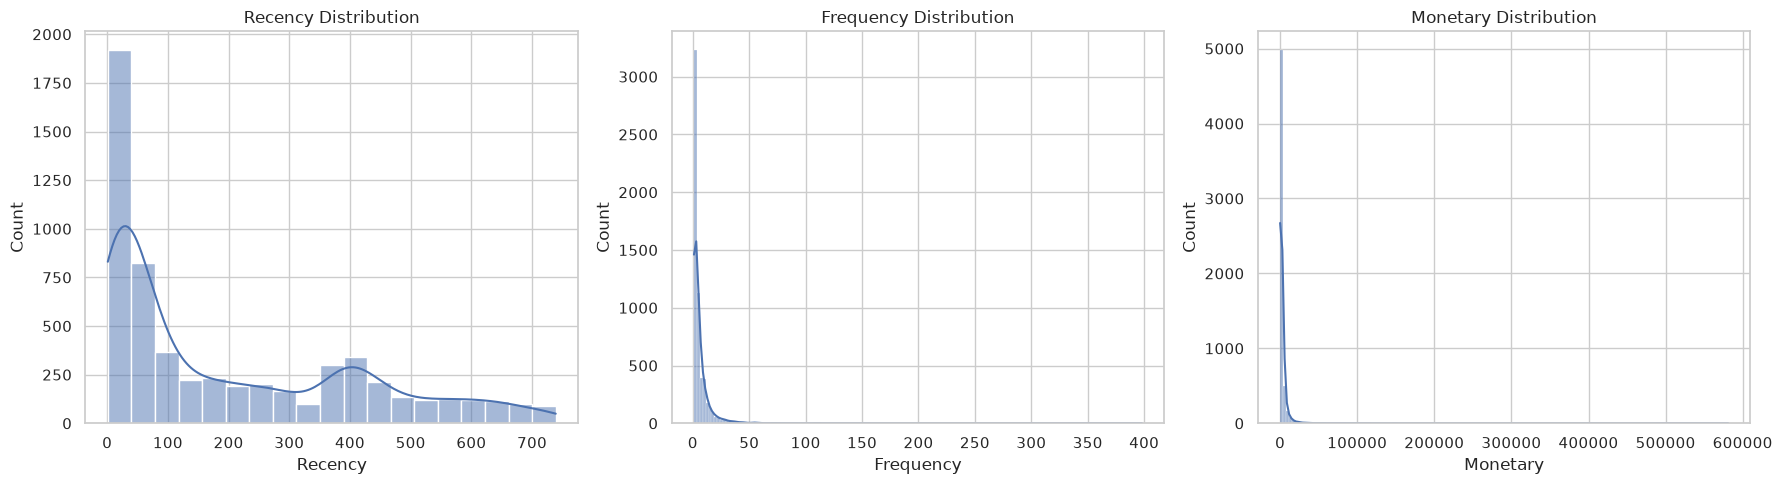

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

## Log-transform RFM

In [38]:
rfm_features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

In [39]:
rfm_log = np.log1p(rfm_features)

In [40]:
rfm_log.describe()

,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000
mean,4.454132,1.549588,6.816979
std,1.559404,0.809447,1.385486
min,0.693147,0.693147,1.373716
25%,3.295837,0.693147,5.838546
50%,4.574711,1.386294,6.767044
75%,5.942799,2.079442,7.718377
max,6.606650,5.988961,13.272485


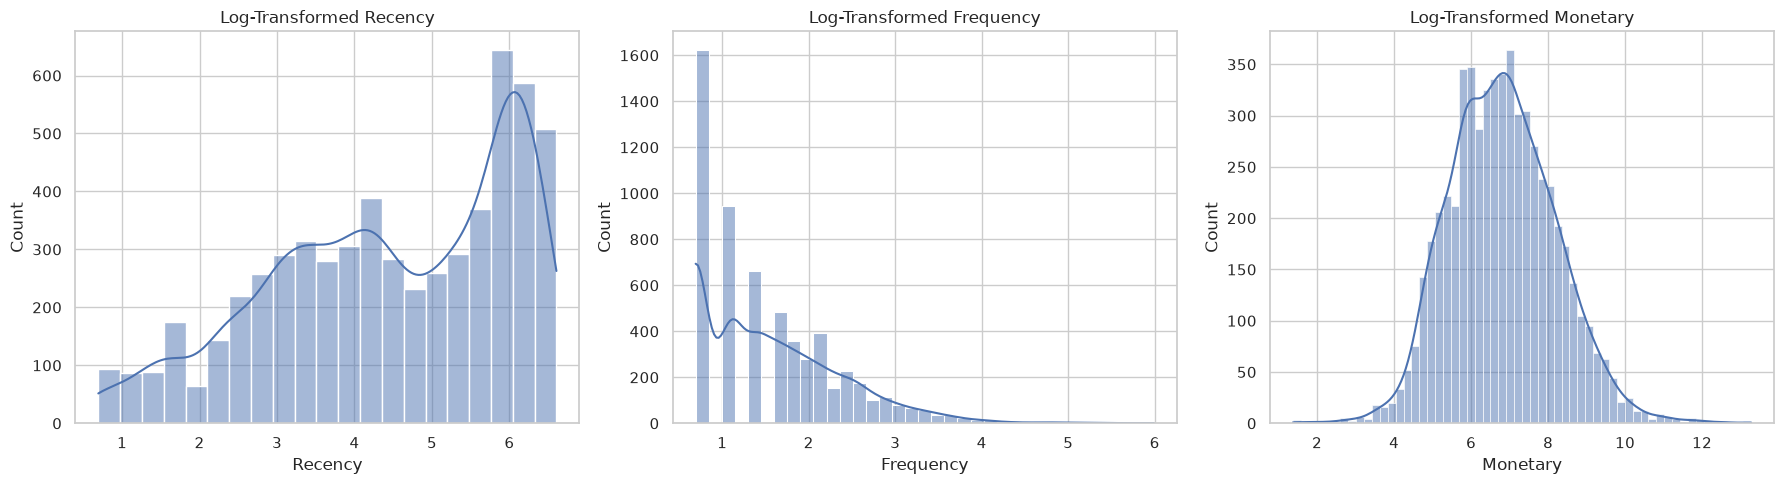

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm_log["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Log-Transformed Recency")

sns.histplot(rfm_log["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Frequency")

sns.histplot(rfm_log["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Log-Transformed Monetary")

plt.tight_layout()
plt.show()

## Scale the features

In [42]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X = scaler.fit_transform(rfm_log)
print("Shape:", X.shape)
print("Mean:", X.mean(axis=0))
print("Std:", X.std(axis=0))

Shape: (5878, 3)
Mean: [-5.07703214e-16  1.88575479e-16  3.77150959e-16]
Std: [1. 1. 1.]


## Save the preprocessing artifacts

In [43]:
import joblib

MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    scaler,
    MODEL_DIR / "rfm_scaler.joblib"
)

['/home/mulata_niguse/AI-Engineering/ecom-customer-segmentation-project/models/rfm_scaler.joblib']

## K-Means baseline

In [44]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
k_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    
    labels = model.fit_predict(X)
    
    silhouette = silhouette_score(X, labels)
    
    k_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette
    })

k_results = pd.DataFrame(k_results)

k_results

,k,inertia,silhouette
0,2,8588.985343,0.438602
1,3,6354.235217,0.347035
2,4,4921.066882,0.365304
3,5,4099.106079,0.342496
4,6,3554.696269,0.334796
5,7,3189.966821,0.301711
6,8,2897.763377,0.296663
7,9,2656.562328,0.292524
8,10,2463.259739,0.289763


## Plot silhouette

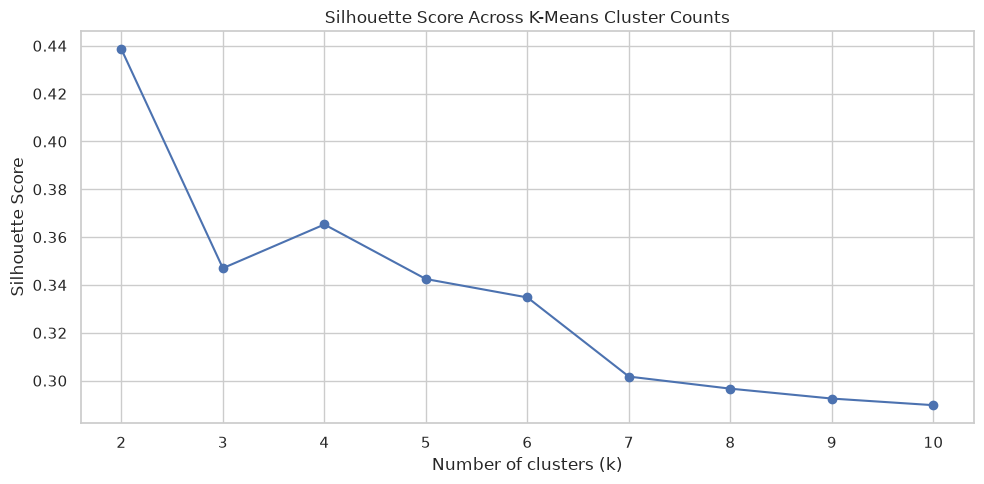

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    k_results["k"],
    k_results["silhouette"],
    marker="o"
)

plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Across K-Means Cluster Counts")

plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

## provisional model for tonight

In [46]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=20
)

kmeans_labels = kmeans.fit_predict(X)

In [47]:
rfm["KMeans_Cluster"] = kmeans_labels
rfm["KMeans_Cluster"].value_counts().sort_index()
rfm.groupby("KMeans_Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

,Recency,Frequency,Monetary
KMeans_Cluster,,,
0,27.463087,19.299497,10755.651659
1,395.889452,1.380325,318.059397
2,28.426741,3.034428,848.377367
3,228.323549,5.086689,1957.154285


## First cluster profile

In [48]:
cluster_profile = (
    rfm
    .groupby("KMeans_Cluster")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .round(2)
)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
KMeans_Cluster,,,,
0,1192,27.46,19.30,10755.65
1,1972,395.89,1.38,318.06
2,1249,28.43,3.03,848.38
3,1465,228.32,5.09,1957.15


## PCA visualization

Explained variance ratio: [0.76356725 0.18744412]
Total explained variance: 0.9510113649304764


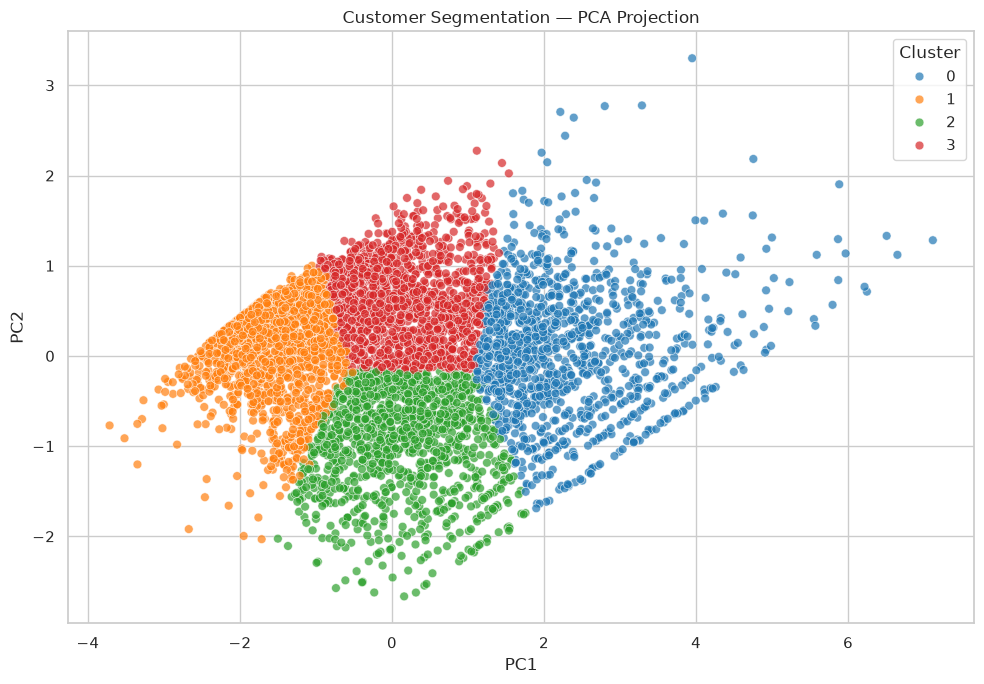

In [49]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": kmeans_labels
})

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=40,
    alpha=0.7
)

plt.title("Customer Segmentation — PCA Projection")
plt.tight_layout()
plt.show()

## Save the clustered customer data

In [50]:
rfm.to_csv(
    PROCESSED_DIR / "rfm_with_kmeans.csv",
    index=False
)